In [169]:
import pandas as pd
import numpy as np
from pathlib import Path

In [170]:
from matplotlib import pyplot as plt

In [171]:
from matplotlib import font_manager

font_dirs = ['/home/miner/fonts']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'
plt.rcParams["mathtext.fontset"] = 'cm'

In [172]:
oranges = (0.99,0.68,0.42,1.0), (0.99,0.55,0.24,1.0), (0.85,0.41,0.07,1.0)
pinks = (0.73,0.54,1.0,1.0), (0.63,0.65,1.0,1.0), (0.80,0.7,0.95,1.0)
greens = (0.13,0.54,0.13,1.0), (0.23,0.64,0.23,1.0), (0.03,0.44,0.03,1.0)
blues = (0.28,0.51,0.71,1.0), (0.38,0.61,0.81,1.0), (0.18,0.41,0.61,1.0)

In [182]:
traj_type='newdiff_deterministic_score'

if traj_type=='olddiff_stochastic_score': #diffusion trajectory
    traj_likelihoods_folder = Path('../../likelihood_results/likelihoodv3/dfmdock_tr/3integrand_traj_flow_pathreset')
    old_traj_likelihoods_folder = Path('../../dfmdock_perturb_tr_likelihood/difftraj_likelihood')
    
    forces_folder = Path('../../likelihood_results/likelihoodv3/dfmdock_tr/3integrand_traj_forces_pathreset')
    old_forces_folder = Path('../../dfmdock_perturb_tr_likelihood/traj_forces.pkl')

elif traj_type=='oldflow_stochastic_score': #flow trajectory
    traj_likelihoods_folder = Path('../../likelihood_results/likelihoodv3/dfmdock_tr/3integrand_flowtraj_flow_pathreset')
    old_traj_likelihoods_folder = Path('../../dfmdock_perturb_tr_likelihood/flowtraj_likelihood')

    forces_folder = Path('../../likelihood_results/likelihoodv3/dfmdock_tr/3integrand_flowtraj_forces_pathreset')
    old_forces_folder = Path('../../dfmdock_perturb_tr_likelihood/flowtraj_forces.pkl')

elif traj_type=='olddiff_deterministic_score': #deterministic score, old diffusion trajectory
    traj_likelihoods_folder = Path('../../likelihood_results/likelihoodv3/dfmdock_trtrained_deterministic/oldsamples/3integrand_traj_flow_pathreset')
    old_traj_likelihoods_folder = Path('../../dfmdock_perturb_tr_likelihood/difftraj_likelihood_deterministic')

    forces_folder = Path('../../likelihood_results/likelihoodv3/dfmdock_trtrained_deterministic/oldsamples/3integrand_traj_forces')
    old_forces_folder = Path('../../dfmdock_perturb_tr_likelihood/traj_forces_deterministic.pkl')

elif traj_type=='oldflow_deterministic_score': #deterministic score, old flow trajectory
    traj_likelihoods_folder = Path('../../likelihood_results/likelihoodv3/dfmdock_trtrained_deterministic/oldsamples/3integrand_flowtraj_flow_pathreset')
    old_traj_likelihoods_folder = Path('../../dfmdock_perturb_tr_likelihood/flowtraj_likelihood_deterministic')

    forces_folder = Path('../../likelihood_results/likelihoodv3/dfmdock_trtrained_deterministic/oldsamples/3integrand_flowtraj_forces')
    old_forces_folder = Path('../../dfmdock_perturb_tr_likelihood/flowtraj_forces_deterministic.pkl')

elif traj_type=='newdiff_deterministic_score': #deterministic score, new diffusion trajectory
    traj_likelihoods_folder = Path('../../likelihood_results/likelihoodv3/dfmdock_trtrained_deterministic/3integrand_traj_flow_40')
    old_traj_likelihoods_folder = None
    
    forces_folder = Path('../../likelihood_results/likelihoodv3/dfmdock_trtrained_deterministic/3integrand_traj_forces')
    old_forces_folder = None

elif traj_type=='newflow_deterministic_score': #deterministic score, new flow trajectory
    traj_likelihoods_folder = Path('../../likelihood_results/likelihoodv3/dfmdock_trtrained_deterministic/3integrand_flowtraj_flow_40')
    old_traj_likelihoods_folder = None
    
    forces_folder = Path('../../likelihood_results/likelihoodv3/dfmdock_trtrained_deterministic/3integrand_flowtraj_forces')
    old_forces_folder = None

else:
    raise ValueError()

out_trajdir = Path(f'single_traj/{traj_type}')
out_trajdir.mkdir(parents=True,exist_ok=True)



if traj_type.startswith('old'):
    ## Old Trajectories (generated with stochastic score model)
    trajectories:list[tuple[str,tuple[str,str]]] = [('2SIC',('2SIC_p30','2SIC_p90')),
                                                    ('1IRA',('1IRA_p22','1IRA_p36'))]
elif traj_type.startswith('new'):
    ## New Trajectories (generated with deterministic score model)
    trajectories:list[tuple[str,tuple[str,str]]] = [('2SIC',('2SIC_p61','2SIC_p119')),
                                                    ('1IRA',('1IRA_p22','1IRA_p36'))]    


# Trajectory Energies

In [184]:
def get_traj_likelihoods(folder):
    single_traj_likelihoods = pd.read_csv(Path(folder)/'likelihood.csv')

    expanded_id = single_traj_likelihoods['id'].str.rsplit("_",n=1,expand=True)
    
    times = expanded_id[1].astype(float)
    ids = expanded_id[0]
    single_traj_likelihoods['id'] = ids
    single_traj_likelihoods['Timestep'] = times
    single_traj_likelihoods['nll'] = -(single_traj_likelihoods['prior:smax_gaussian'] + single_traj_likelihoods['integrand:TotalIntegrand'])/3
    
    single_traj_likelihoods = single_traj_likelihoods.iloc[::-1,:]

    all_ids = np.unique(ids)

    resdict = {}
    for id in all_ids:
        resdict[id] = single_traj_likelihoods[single_traj_likelihoods['id']==id].reset_index()
        
    return resdict

def get_old_traj_likelihoods(folder):
    resdict = {}
    folder = Path(folder)
    if not folder.exists(): raise FileNotFoundError(folder)
    for likelihood in folder.glob("*_likelihood.csv"):
        id = likelihood.name.split("_likelihood.csv")[0]
        resdict[id] = pd.read_csv(likelihood)
    return resdict

traj_likelihoods = get_traj_likelihoods(traj_likelihoods_folder)
if old_traj_likelihoods_folder is not None:
    old_traj_likelihoods = get_old_traj_likelihoods(old_traj_likelihoods_folder)

    for id,d in old_traj_likelihoods.items():
        if 'Timestep' in d.columns:
            raise ValueError()
        d['Timestep'] = traj_likelihoods[id]['Timestep']

In [185]:
def plot_likelihood(likelihood_df,color,name=None):
    plt.plot(likelihood_df.Timestep,likelihood_df.nll, marker='o', linestyle='-', markersize=1.5, alpha=0.8, linewidth=0.7, c=color, label=name)

In [186]:
from typing import Any, Iterable, Literal


#colors: Iterable of tuples (old,new).
def compare_likelihoods(id:str,trajs:Iterable[str],oldnew:Literal['old','new','both']='both',colors:Iterable[tuple[Any,Any]]=((oranges[0],greens[0]),(pinks[0],blues[0]))):
    for traj,(oldcolor,newcolor) in zip(trajs,colors):
        if oldnew in ('old','both') and old_traj_likelihoods is not None:
            plot_likelihood(old_traj_likelihoods[traj], color=oldcolor, name=f'old {traj}')

        if oldnew in ('new','both') and traj_likelihoods is not None:
            plot_likelihood(traj_likelihoods[traj], color=newcolor, name=f'new {traj}')

    plt.xlabel('Diffusion time $t$')
    plt.ylabel(r'Learned Energy $-\log\,p_{0}(\mathbf{r}_{t})$')
    # plt.ylim(2.4, 6.4)
    fig = plt.gcf()
    fig.set_size_inches(3, 2)
    fig.set_dpi(300)
    plt.yticks([3.5,4,4.5,5,5.5,6])
    plt.legend(fontsize='xx-small')
    plt.title(f"{traj_type}: {id} Trajectories")
    plt.savefig(out_trajdir/f'{id}_Trajectories.png', dpi=300, bbox_inches='tight')

compare_likelihoods(*trajectories[0])
plt.figure()
compare_likelihoods(*trajectories[1])

KeyError: '2SIC_p61'

## Seed Experiments

In [177]:
# #forces & divergence across multiple seeds
# seeded_likelihoods = [(0,traj_likelihoods)]
# seeded_likelihoods += [(i,get_traj_likelihoods(traj_likelihoods_folder/f'seed{i}')) for i in range(10,50,10)]

In [178]:
# id = '2SIC_p90'
# for id in ['2SIC_p30','2SIC_p90','1IRA_p22','1IRA_p36']:
#     plt.figure()
#     for seed,likedict in seeded_likelihoods:
#         plot_likelihood(likedict[id],color=None,name=f'seed{seed}')
#     plot_likelihood(old_traj_likelihoods[id],color='black',name='old')
    
#     plt.xlabel('Diffusion time $t$')
#     plt.ylabel(r'Learned Energy $-\log\,p_{0}(\mathbf{r}_{t})$')
    
#     fig = plt.gcf()
#     fig.set_size_inches(3, 2)
#     fig.set_dpi(300)
#     plt.legend(fontsize='xx-small')
#     plt.title(id)

# Trajectory Forces

In [179]:
import pickle
with open(old_forces_folder, 'rb') as f:
    traj_forces = pickle.load(f)
old_traj_force_dict = {item['id'].split('/')[-1].split('.')[0]: item for item in traj_forces}
try:
    old_traj_force_dict = {k.split("trajectory_",1)[1]:v for k,v in old_traj_force_dict.items()}
except:
    pass

FileNotFoundError: [Errno 2] No such file or directory: '../../dfmdock_perturb_tr_likelihood/traj_forces_deterministic.pkl'

In [ ]:
from pathlib import Path
import pandas as pd

def read_forces(forces_folder):
    index = pd.read_csv(forces_folder/'force_index.csv')
    
    cols = ["Offset_Tr_X", "Offset_Tr_Y", "Offset_Tr_Z"]
    score_cols = [f"score:{col}" for col in cols]
    pos_cols = [f"pos:{col}" for col in cols]
    
    traj_force_dict = {}
    for row in index.itertuples():
        id = row.id
        file = row.Forces_CSV
        forcedict = traj_force_dict[id] = {}
        forces = pd.read_csv(Path('..')/file)
        forcedict['id'] = id
        forcedict['time'] = np.array(forces['Timestep'].values[::-1])
        forcedict['score'] = np.array(forces[score_cols].values[::-1])
        forcedict['divergence'] = np.array(forces['Divergence'][::-1])
        forcedict['diff_coeff'] = np.array(forces['Diffusion_Coeff'][::-1])
        forcedict['pos'] = np.array(forces[pos_cols].values[::-1])
    return traj_force_dict


traj_force_dict = read_forces(forces_folder)

for id,d in old_traj_force_dict.items():
    if 'time' not in d:
        # raise ValueError()
        d['time'] = np.linspace(0.975,0,40)#np.array(range(0,40))[::-1]/40
    elif d['time'].ndim == 2:
        d['time'] = d['time'][:,0]

In [ ]:
def plot_forces_xyz(id_dict,colors,scaled=False,name=None):
    scale = -1/2*np.squeeze(id_dict['diff_coeff'])**2 if scaled else 1
    plt.plot(id_dict['time'], scale*id_dict['score'][:,0], marker='o', linestyle='-', c=colors[0], markersize=1.5, alpha=0.8, linewidth=0.7,label=f"{name} x" if name else name)
    plt.plot(id_dict['time'], scale*id_dict['score'][:,1], marker='s', linestyle='-', c=colors[1], markersize=1.5, alpha=0.8, linewidth=0.7,label=f"{name} y" if name else name)
    plt.plot(id_dict['time'], scale*id_dict['score'][:,2], marker='v', linestyle='-', c=colors[2], markersize=1.5, alpha=0.8, linewidth=0.7,label=f"{name} z" if name else name)

def plot_forces_mag(id_dict,color,scaled=False,name=None):
    scale = -1/2*np.squeeze(id_dict['diff_coeff'])[:,None]**2 if scaled else 1
    plt.plot(id_dict['time'],np.linalg.norm(scale*id_dict['score'],axis=1),marker='o', linestyle='-', c=color, markersize=1.5, alpha=0.8, linewidth=0.7,label=name)

def plot_divergence(id_dict,color,scaled=False,name=None):
    scale = -1/2*np.squeeze(id_dict['diff_coeff'])**2 if scaled else 1
    plt.plot(id_dict['time'],scale*np.squeeze(id_dict['divergence']),marker='o', linestyle='-', c=color, markersize=1.5, alpha=0.8, linewidth=0.7,label=name)

In [ ]:
from typing import Literal

def compare_forces_mag(id:str,trajs:Iterable[str],oldnew:Literal['old','new','both']='both',colors:Iterable[tuple[Any,Any]]=((oranges[0],greens[0]),(pinks[0],blues[0])),scaled=False):
    for traj,(oldcolor,newcolor) in zip(trajs,colors):
        if oldnew in ('old','both') and old_traj_force_dict is not None:
            plot_forces_mag(old_traj_force_dict[traj], color=oldcolor, scaled=scaled, name=f'old {traj}')

        if oldnew in ('new','both') and traj_likelihoods is not None:
            plot_forces_mag(traj_force_dict[traj], color=newcolor, scaled=scaled, name=f'new {traj}')
        
    if scaled:
        plt.ylabel(r'$||-\frac{1}{2}g(t)^2 \nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})||$')
    else:
        plt.ylabel(r'$||f_{\theta} (\mathbf{r}_t,t)||=||\nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})||$')
    plt.xlabel('Diffusion time $t$')

    fig = plt.gcf()
    plt.legend(fontsize='xx-small')
    fig.set_size_inches(3, 2)
    fig.set_dpi(300)
    plt.savefig(out_trajdir/f'{id}{('_' + oldnew) if oldnew != 'both' else ''}_single_traj{'_scaled' if scaled else ''}_force_mag.png', dpi=300, bbox_inches='tight')
    plt.title(f"{id} {'Scaled ' if scaled else ''}Magnitudes: {'Comparison' if oldnew == 'both' else oldnew}")


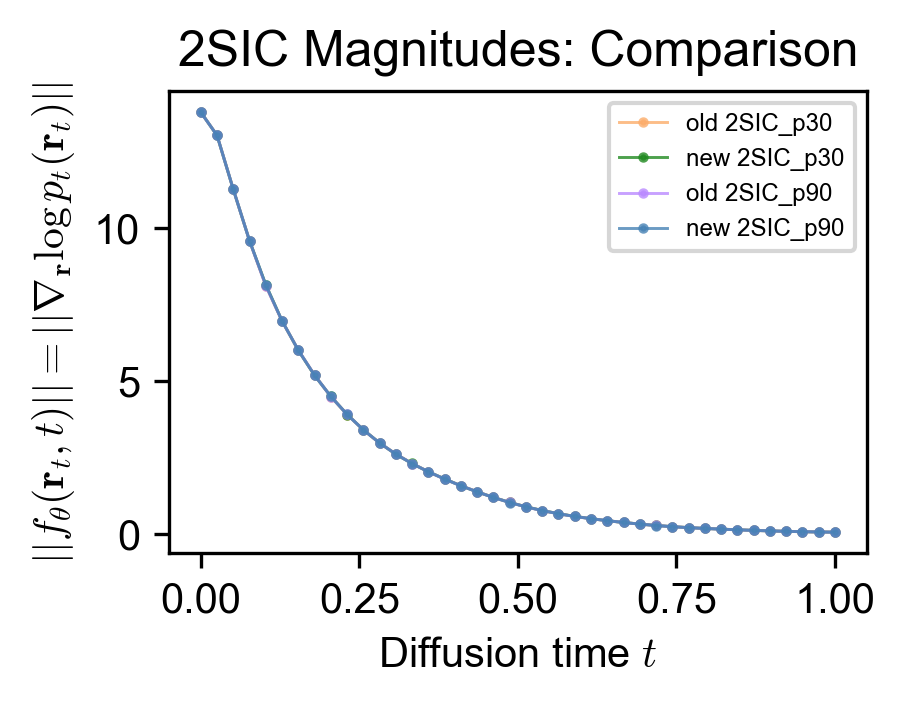

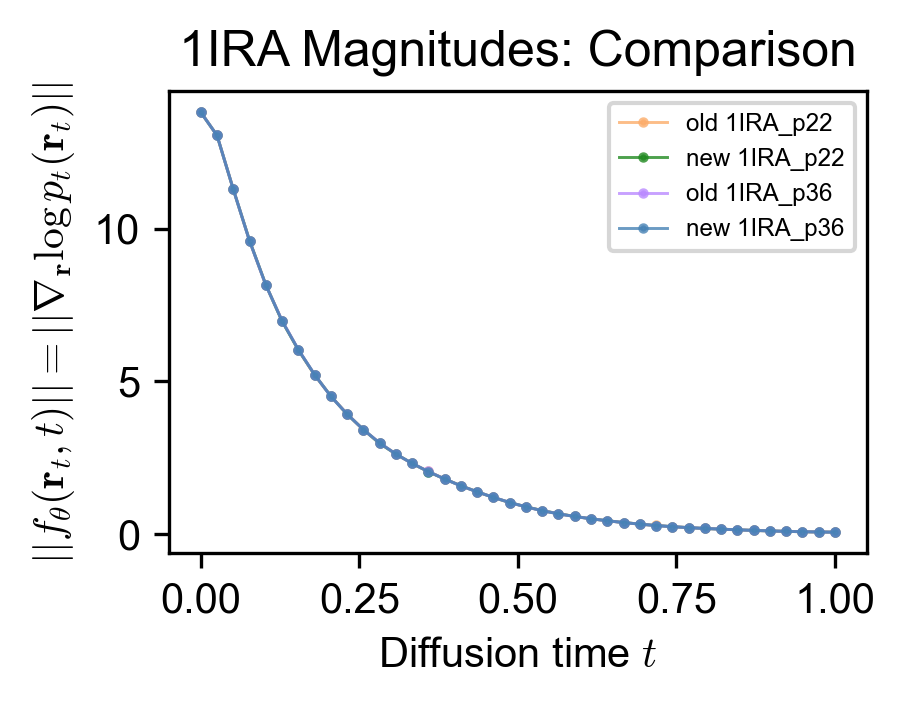

In [ ]:
compare_forces_mag(*trajectories[0])
plt.figure()
compare_forces_mag(*trajectories[1])

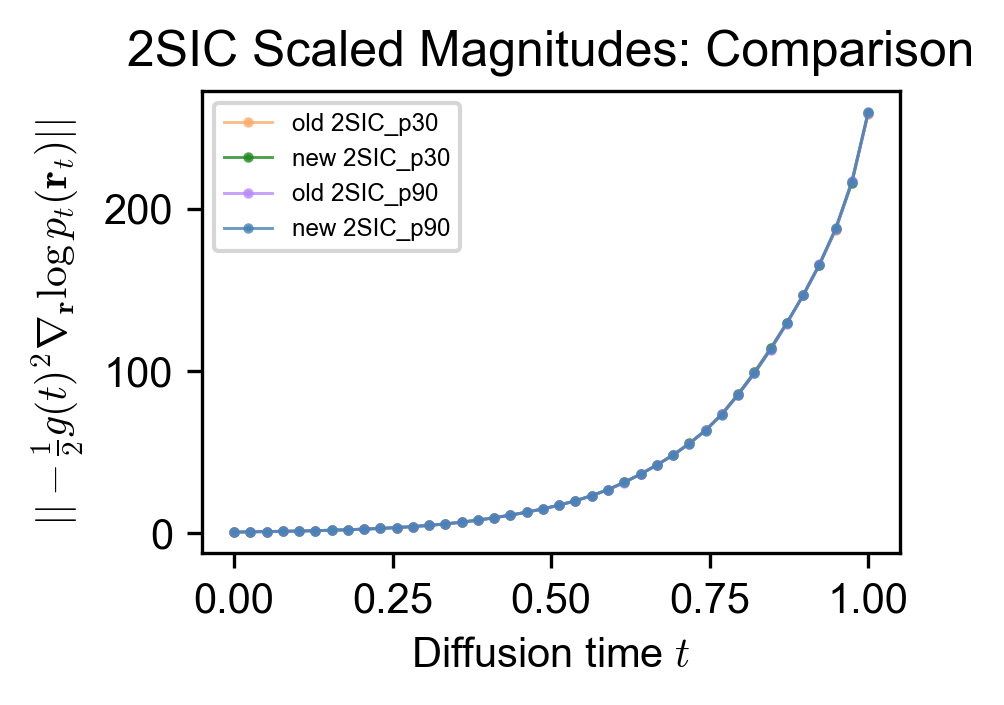

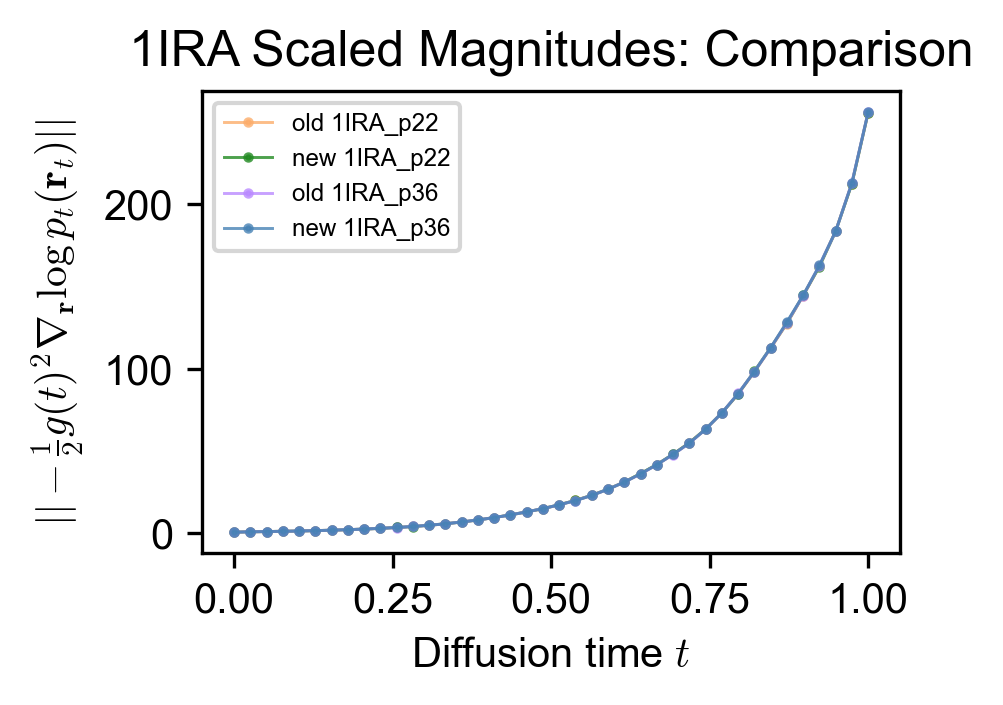

In [ ]:
compare_forces_mag(*trajectories[0],scaled=True)
plt.figure()
compare_forces_mag(*trajectories[1],scaled=True)

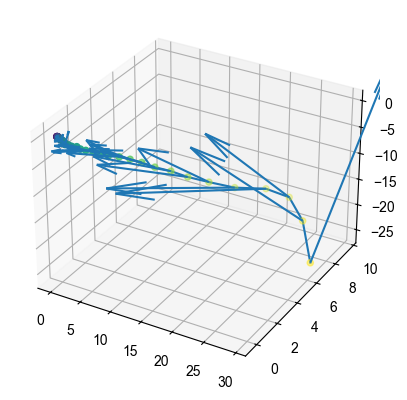

In [ ]:
## Plot forces in 3d over the trajectory
# %matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

for id in traj_force_dict:
    X,Y,Z = traj_force_dict[id]['pos'].T
    # score = old_traj_force_dict[id]['score'][::-1]
    score = traj_force_dict[id]['score']
    score = score/2*np.array(traj_force_dict[id]['diff_coeff']**2)[:,None]
    FX,FY,FZ = score.T/10

    ax.quiver(X,Y,Z,FX,FY,FZ)#,color=traj_force_dict[id]['time'])
    ax.plot(X,Y,Z)#,c=traj_force_dict[id]['time'])
    ax.scatter(X,Y,Z,c=traj_force_dict[id]['time'])

    break

    

In [ ]:
from typing import Literal


def compare_forces_xyz(id:str,trajs:Iterable[str],oldnew:Literal['old','new','both'],colors:Iterable[tuple[Any,Any]]=((oranges,greens),(pinks,blues)),scaled=False):
    for traj,(oldcolors,newcolors) in zip(trajs,colors):
        if oldnew in ('old','both') and old_traj_force_dict is not None:
            plot_forces_xyz(old_traj_force_dict[traj], colors=oldcolors, scaled=scaled, name=f'old {traj}')

        if oldnew in ('new','both') and traj_likelihoods is not None:
            plot_forces_xyz(traj_force_dict[traj], colors=newcolors, scaled=scaled, name=f'new {traj}')
    
    plt.plot(np.linspace(0,1,100),np.zeros(100),linestyle='--',color='gray',linewidth=0.8)
    if scaled:
        plt.ylabel(r'$-\frac{1}{2}g(t)^2 \nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
    else:
        plt.ylabel(r'$f_{\theta} (\mathbf{r}_t,t)=\nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
    plt.xlabel('Diffusion time $t$')

    fig = plt.gcf()
    fig.set_size_inches(3, 2)
    fig.set_dpi(300)
    plt.savefig(out_trajdir/f'{id}{('_' + oldnew) if oldnew != 'both' else ''}_single_traj{'_scaled' if scaled else ''}_force_xyz.png', dpi=300, bbox_inches='tight')
    plt.title(f"{id} {'Scaled ' if scaled else ''}Forces: {'Comparison' if oldnew == 'both' else oldnew}")
    plt.legend(fontsize='xx-small')


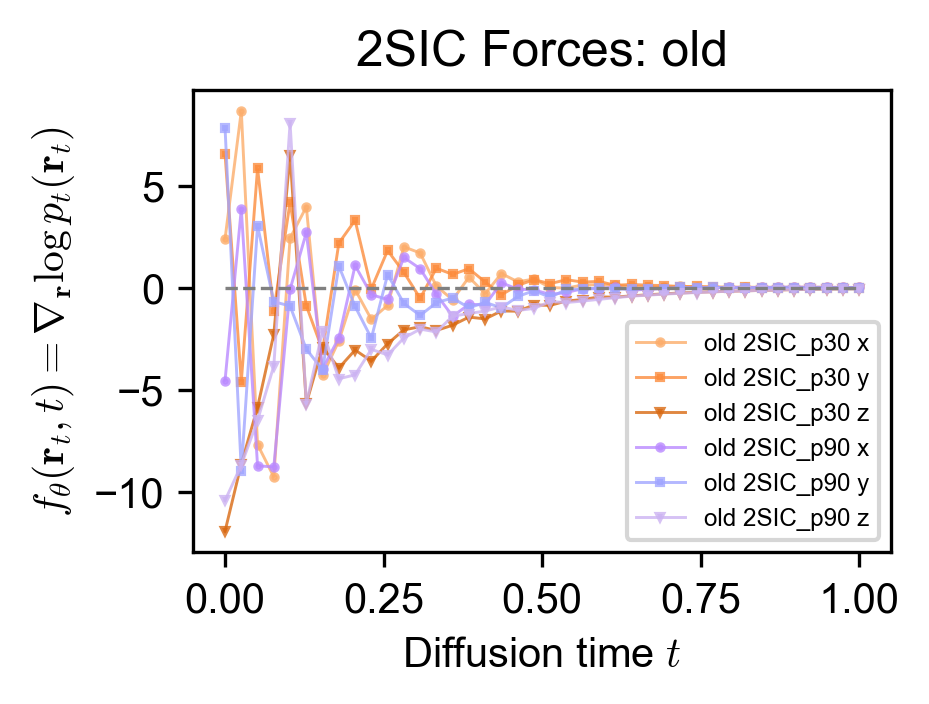

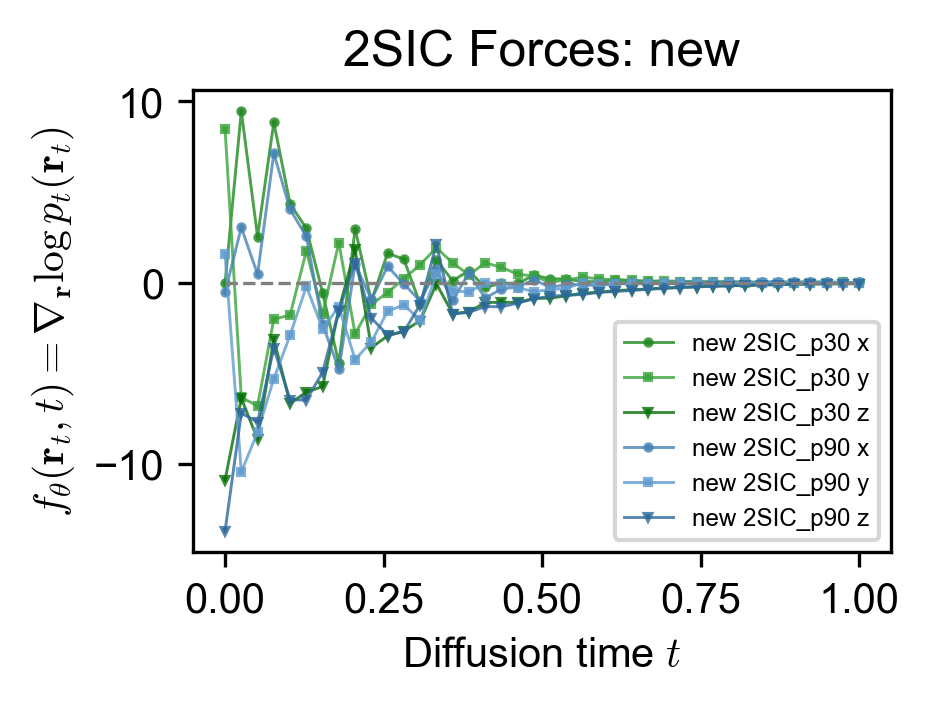

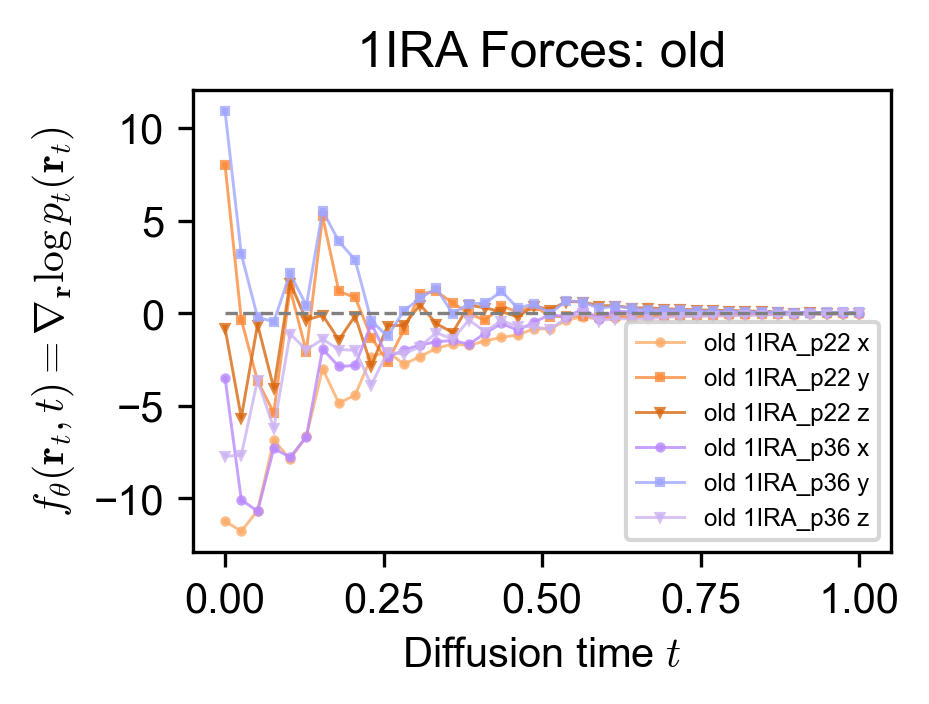

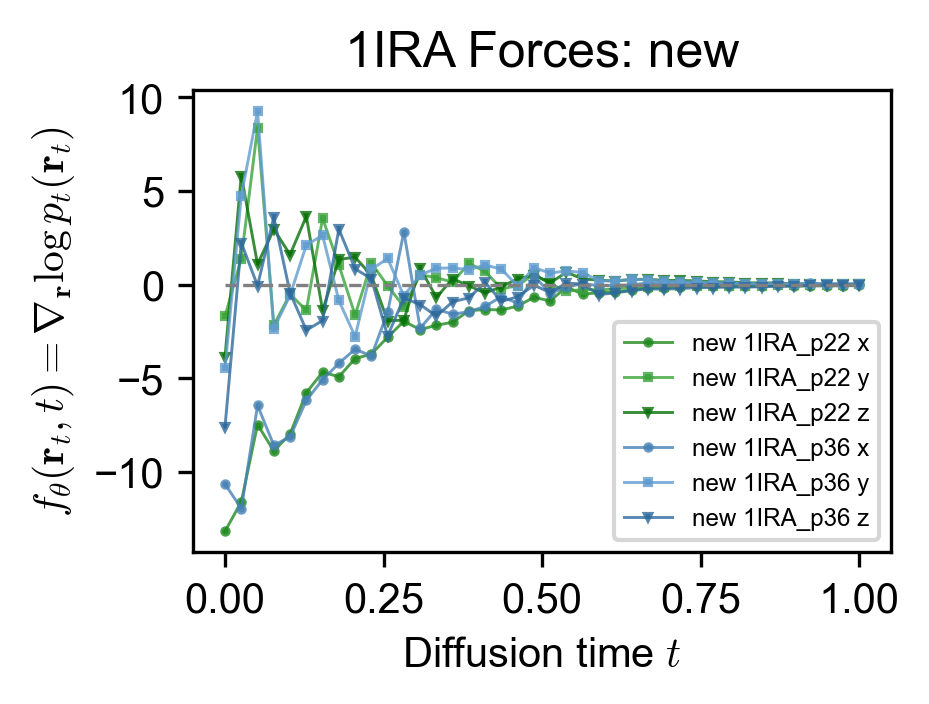

In [ ]:
compare_forces_xyz(*trajectories[0],'old')
plt.figure()
compare_forces_xyz(*trajectories[0],'new')
plt.figure()
compare_forces_xyz(*trajectories[1],'old')
plt.figure()
compare_forces_xyz(*trajectories[1],'new')

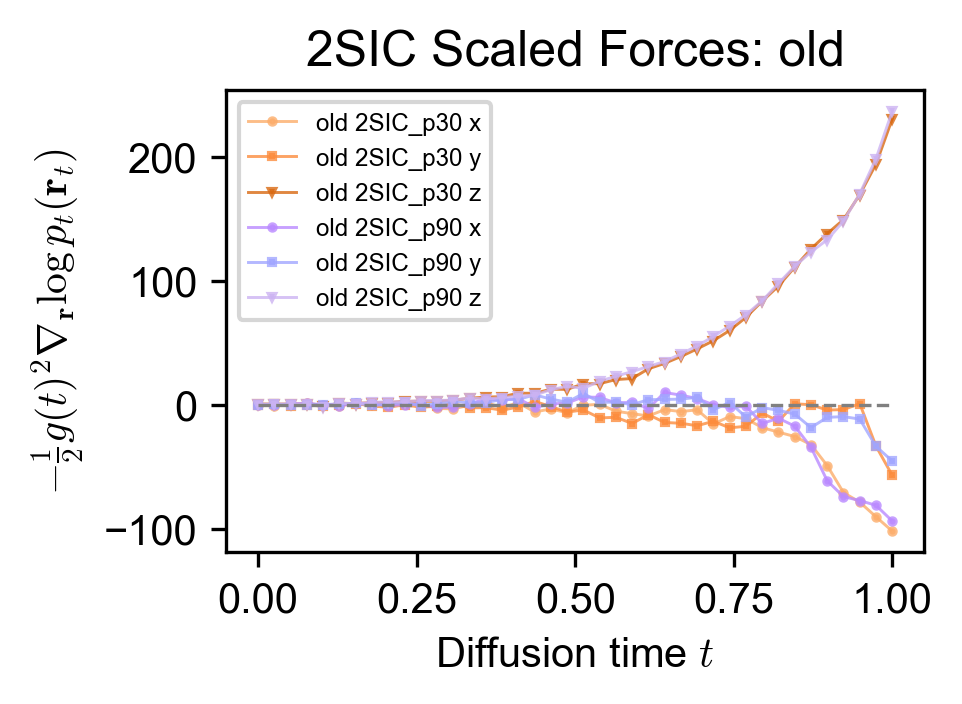

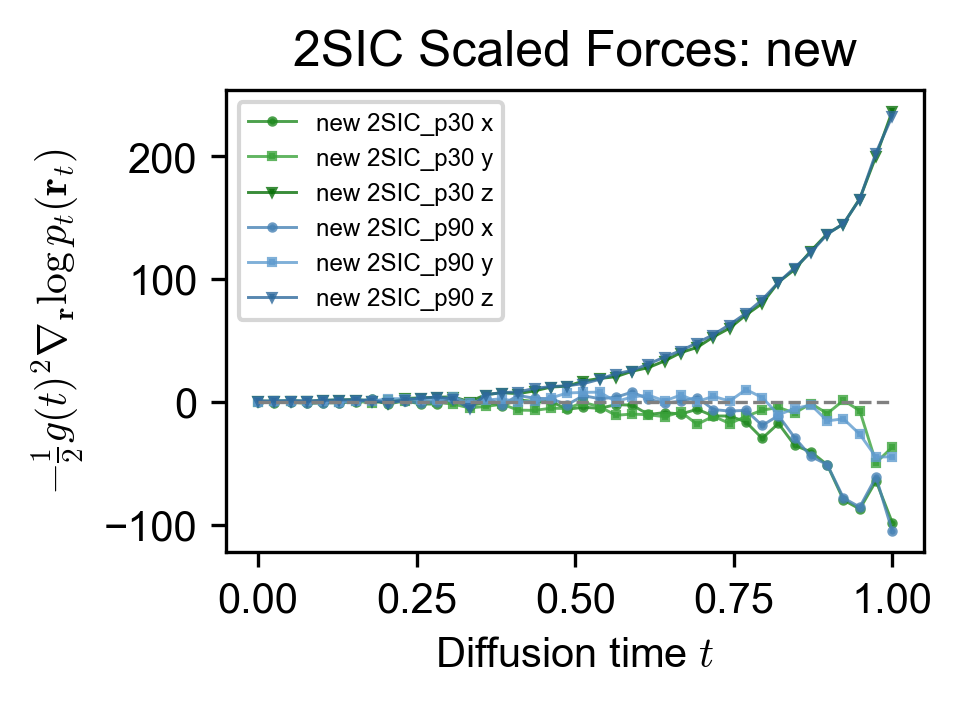

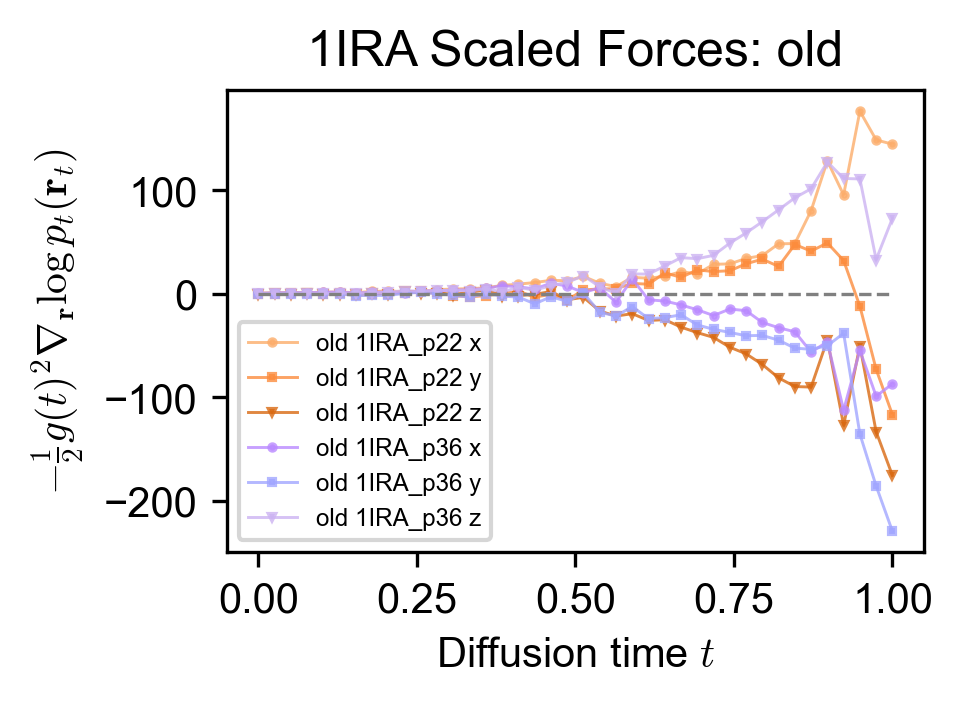

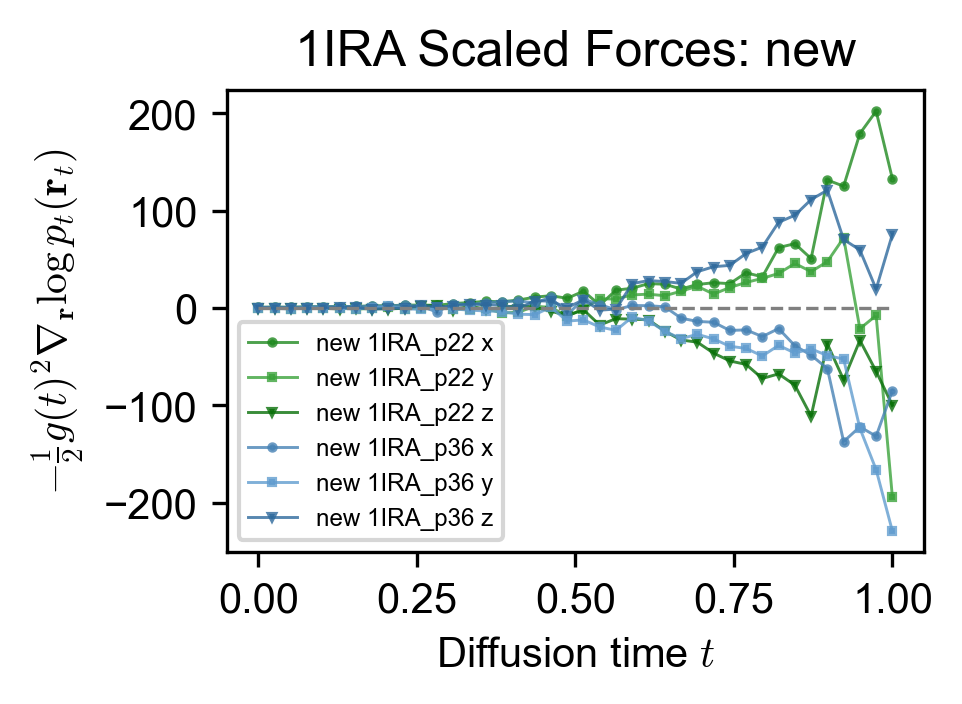

In [ ]:
compare_forces_xyz(*trajectories[0],'old',scaled=True)
plt.figure()
compare_forces_xyz(*trajectories[0],'new',scaled=True)
plt.figure()
compare_forces_xyz(*trajectories[1],'old',scaled=True)
plt.figure()
compare_forces_xyz(*trajectories[1],'new',scaled=True)

In [ ]:
def compare_divergence(id:str,trajs:Iterable[str],oldnew:Literal['old','new','both']='both',colors:Iterable[tuple[Any,Any]]=((oranges[0],greens[0]),(pinks[0],blues[0])),scaled=False):
    for traj,(oldcolor,newcolor) in zip(trajs,colors):
        if oldnew in ('old','both') and old_traj_force_dict is not None:
            plot_divergence(old_traj_force_dict[traj], color=oldcolor, scaled=scaled, name=f'old {traj}')

        if oldnew in ('new','both') and traj_likelihoods is not None:
            plot_divergence(traj_force_dict[traj], color=newcolor, scaled=scaled, name=f'new {traj}')
    
    plt.plot(np.linspace(0,1,100),np.zeros(100),linestyle='--',color='gray',linewidth=0.8)
    if scaled:
        plt.ylabel(r'$-\frac{1}{2}g(t)^2 \nabla_{\mathbf{r}} \cdot \nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
    else:
        plt.ylabel(r'$\nabla_{\mathbf{r}} \cdot \nabla_{\mathbf{r}} \log p_{t}(\mathbf{r}_{t})$')
    plt.xlabel('Diffusion time $t$')

    fig = plt.gcf()
    fig.set_size_inches(3, 2)
    fig.set_dpi(300)
    plt.savefig(out_trajdir/f'{id}{('_' + oldnew) if oldnew != 'both' else ''}_single_traj{'_scaled' if scaled else ''}_divergence.png', dpi=300, bbox_inches='tight')
    plt.title(f"{id} {'Scaled ' if scaled else ''}Divergence: {'Comparison' if oldnew == 'both' else oldnew}")
    plt.legend(fontsize='xx-small')

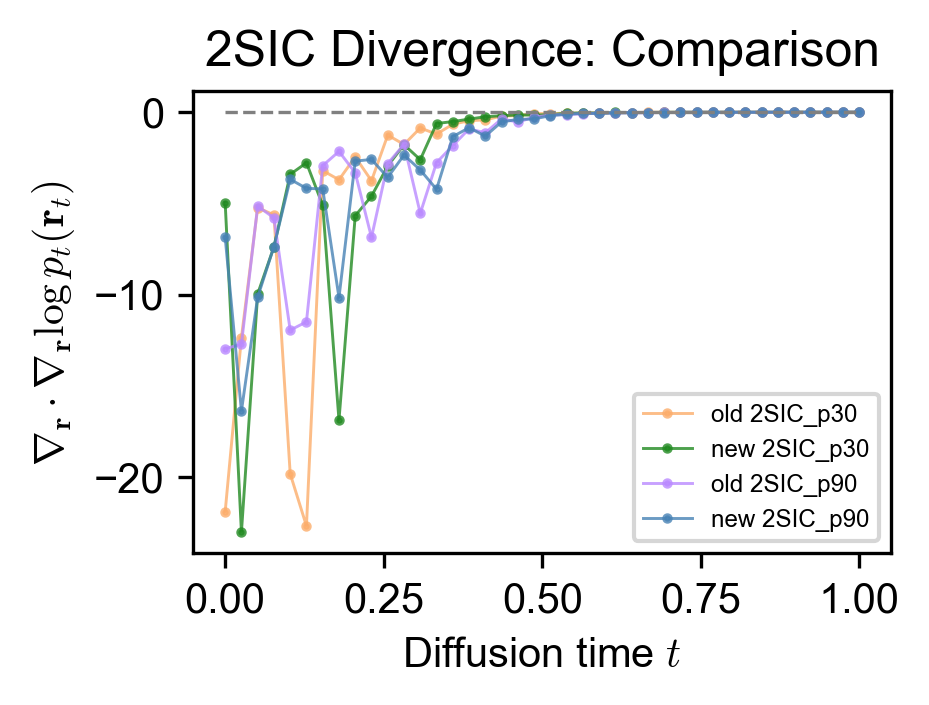

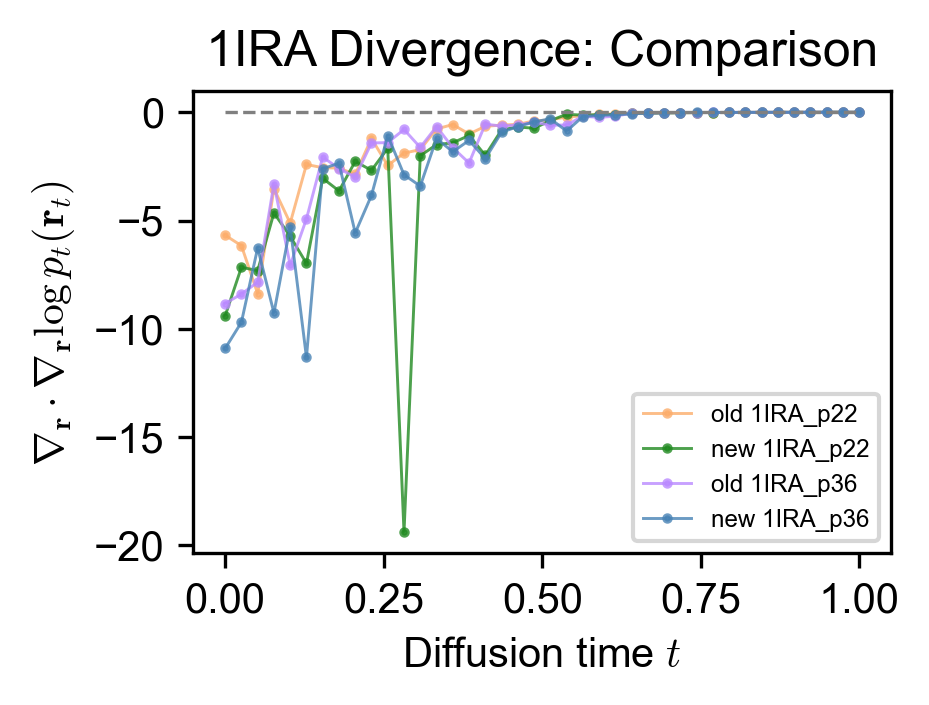

In [ ]:
compare_divergence(*trajectories[0])
plt.figure()
compare_divergence(*trajectories[1])

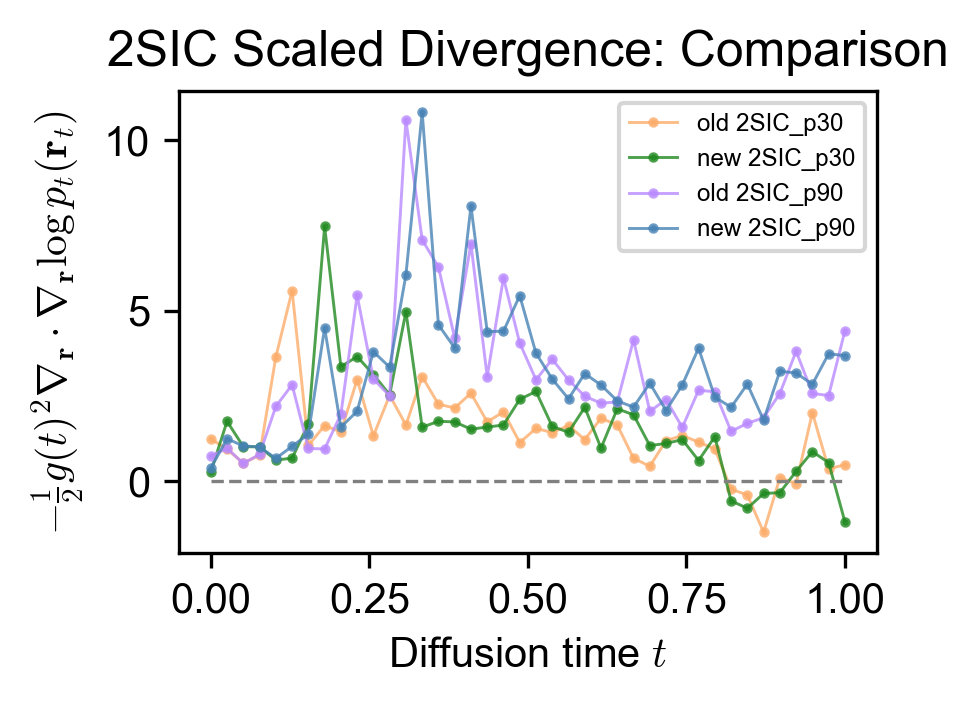

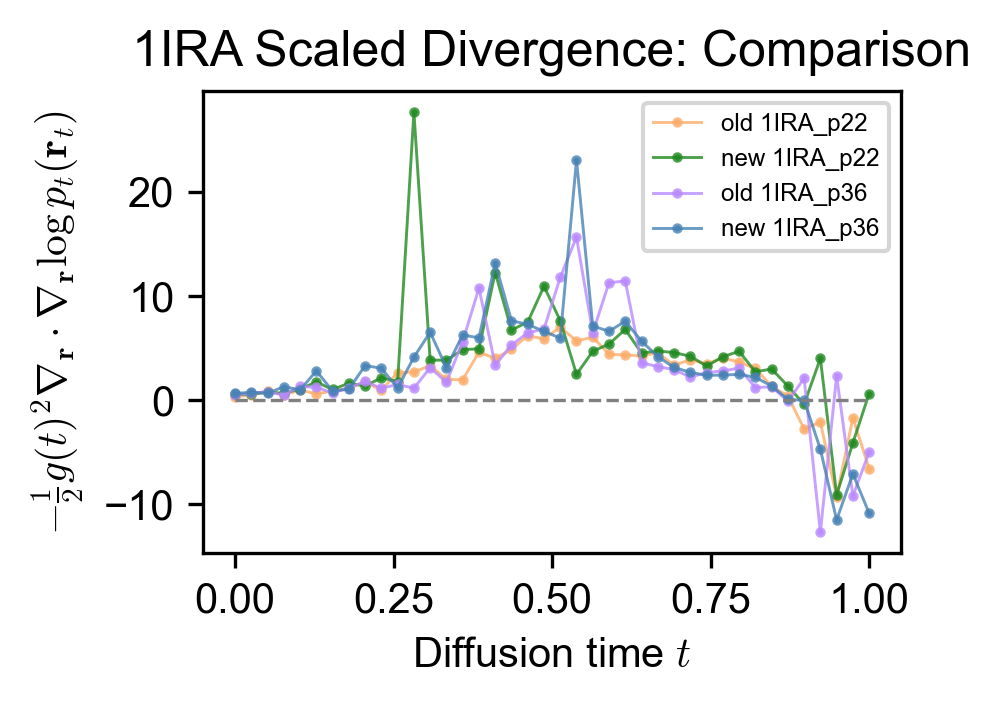

In [ ]:
compare_divergence(*trajectories[0],scaled=True)
plt.figure()
compare_divergence(*trajectories[1],scaled=True)

## Seed Experiments

In [ ]:
# #forces & divergence across multiple seeds
# seeded_forces = [(0,traj_force_dict)]
# seeded_forces += [(i,read_forces(forces_folder/f'seed{i}')) for i in range(10,200,10)]


In [ ]:
# seeded_forces[0][1]['2SIC_p30']['score'][0] - seeded_forces[1][1]['2SIC_p30']['score'][0]

In [ ]:
# for id in ['2SIC_p30','2SIC_p90','1IRA_p22','1IRA_p36']:
#     plt.figure()
#     for seed,forces in seeded_forces:
#         plot_divergence(forces[id],color=None,name=f'seed{seed}')

#     plot_divergence(old_traj_force_dict[id],color='black',name='old')
#     fig = plt.gcf()
#     fig.set_size_inches(3, 2)
#     fig.set_dpi(300)    
#     plt.title(id)
#     plt.legend(fontsize='xx-small')